# K - Nearest Neighbours

## 1. Setup 

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from model_wrappers import ThresholdedClassifier, OutlierCapper
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

FINAL_K = 30  # number of features selected — matches the shared value used in Preprocess_expanded.ipynb

In [2]:
try:
    X_train_raw = joblib.load("X_train_raw.pkl")
    X_test_raw = joblib.load("X_test_raw.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Loaded successfully
X_train_raw: (3996, 42) y_train: (3996,)
X_test_raw : (1000, 42) y_test : (1000,)


## 1.2 Results Log 
Tracks accuracy at every stage. **All exploratory/comparison entries use cross-validation on training data only** (`log_cv`) — the test set is not touched until the single \"Final Model Declaration\" section at the end (`log_test`), which is used exactly once. `candidate_models` keeps a reference to the actual fitted pipeline for each candidate, so the winning one can be retrieved and saved without having to re-decide anything by hand.

In [3]:
results_log = []
candidate_models = {}

def log_cv(name, acc, model=None):
    """Log a cross-validated (train-only) accuracy estimate."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "CV (train only)"})
    if model is not None:
        candidate_models[name] = model
    print(f"[Logged - CV] {name}: {acc:.4f}")
    return acc

def log_test(name, y_true, y_pred):
    """Log a genuine held-out test accuracy. Reserved for the FINAL declared model only."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "TEST (final, touched once)"})
    print(f"[Logged - TEST] {name}: {acc:.4f}")
    return acc

## 2. Baseline Model 
Untuned KNN (`n_neighbors=15`, arbitrary), wrapped in a `Pipeline` with feature selection and scaling so it's evaluated the same leakage-free way as every other candidate below.

In [4]:
baseline_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15, weights="uniform"))
])

try:
    cv_scores = cross_val_score(baseline_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during baseline cross-validation: {e}")
else:
    print("Baseline 10-fold CV Accuracy:", cv_scores.mean())
    log_cv("Baseline (n_neighbors=15)", cv_scores.mean(), model=baseline_pipeline)

Baseline 10-fold CV Accuracy: 0.7830256892230576
[Logged - CV] Baseline (n_neighbors=15): 0.7830


## 3. Hyperparameter Tuning 
Grid Search now tunes the full `Pipeline` (selector + scaler + classifier) together, so `SelectKBest` and `StandardScaler` are refit independently inside every one of the 10 folds — not fit once beforehand. `weights` is fixed to `'uniform'` throughout, avoiding the self-matching effect of `'distance'` weighting that inflated training accuracy earlier in this project.

In [5]:
pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": range(1, 61),
    "clf__weights": ["uniform"],
    "clf__metric": ["euclidean", "manhattan"]
}

try:
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train_raw, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_pipeline = grid_search.best_estimator_
    print("Best Hyperparameters:", grid_search.best_params_)
    print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")
    log_cv("Grid Search Tuned", grid_search.best_score_, model=best_pipeline)

Best Hyperparameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
Best Cross-Validated Accuracy: 0.8060
[Logged - CV] Grid Search Tuned: 0.8060


## 4. Training-Set Sanity Check 
A quick check for gross overfitting using training data only — the real generalization gap is confirmed once, honestly, in the Final Model Declaration section using the untouched test set.

In [6]:
try:
    train_accuracy = best_pipeline.score(X_train_raw, y_train)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating training accuracy: {e}")
else:
    print("Training Accuracy (best pipeline):", train_accuracy)
    print("(compare against the 10-fold CV accuracy above — a very large gap would flag overfitting)")

Training Accuracy (best pipeline): 0.8888888888888888
(compare against the 10-fold CV accuracy above — a very large gap would flag overfitting)


## 5. Model Stability — Cross-Validation & Accuracy vs. K 
Fold-by-fold view of the tuned pipeline's 10-fold CV accuracy, and an Accuracy vs. K sweep — each K value below is wrapped in its own fresh `Pipeline`, so selection/scaling are refit per fold for every K tested, not just for the final chosen one. \n\n**A note on \"loss curves\" for KNN:** unlike ANN, KNN has no training-time optimization loop — it's a *\"lazy learner\"* that just stores the data, so there's no loss to plot. The Accuracy vs. K plot below is the closest honest equivalent, playing the same diagnostic role.

Fold scores: [0.825      0.8275     0.7875     0.8225     0.81       0.7875
 0.8245614  0.81203008 0.78195489 0.77694236]
Average CV Accuracy: 0.8055488721804511


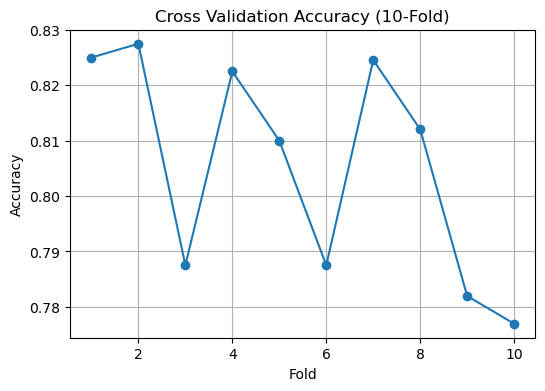

In [7]:
try:
    cv_scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print("Fold scores:", cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

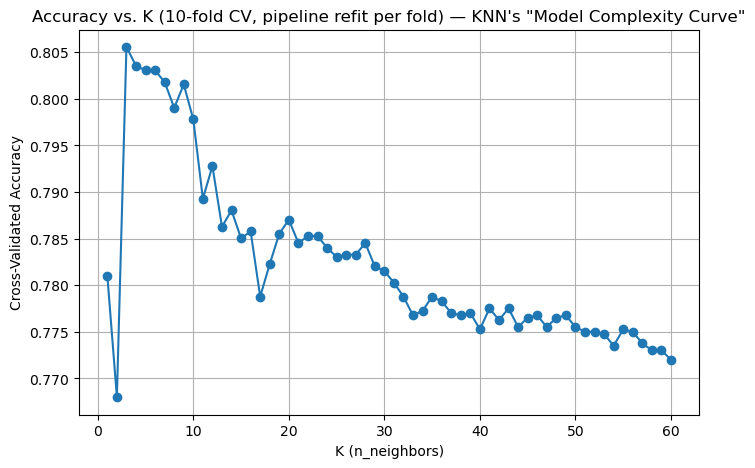

In [8]:
best_metric = grid_search.best_params_["clf__metric"]

k_range = range(1, 61)
k_scores = []

try:
    for k in k_range:
        temp_pipeline = Pipeline([
            ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
            ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=k, weights="uniform", metric=best_metric))
        ])
        scores = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
        k_scores.append(scores.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during K sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, k_scores, marker="o")
    plt.title("Accuracy vs. K (10-fold CV, pipeline refit per fold) — KNN's \"Model Complexity Curve\"")
    plt.xlabel("K (n_neighbors)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic)
The optimal threshold is found using **out-of-fold predicted probabilities on the training set only** (`cross_val_predict`), so the test set plays no role in choosing it — the ROC curve and Youden's J (`Sensitivity + Specificity − 1`) are both computed against `y_train`, not `y_test`.

In [9]:
try:
    y_train_probs = cross_val_predict(best_pipeline, X_train_raw, y_train, cv=10, method="predict_proba")[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_train_pred_optimal = (y_train_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    cv_thresholded_acc = accuracy_score(y_train, y_train_pred_optimal)
    print("Out-of-fold accuracy at this threshold (train, CV-based):", cv_thresholded_acc)
    log_cv("Grid Search + Youden's J", cv_thresholded_acc, model=(best_pipeline, best_threshold))

Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): 0.6667
Youden's J at this threshold: 0.6049
Out-of-fold accuracy at this threshold (train, CV-based): 0.8055555555555556
[Logged - CV] Grid Search + Youden's J: 0.8056


## 6.2 Gaussian Weighted Voting 
KNN's model-specific \"extra formula\": instead of `uniform` (every neighbor votes equally) or `distance` (weight = 1/d, which can blow up sharply as d → 0), a **Gaussian kernel weight** gives closer neighbors a smoothly decaying influence: $$w_i = \\exp\\left(-\\frac{d_i^2}{2\\sigma^2}\\right)$$ This avoids the near-total self-voting blowup that caused the earlier 100% training-accuracy issue with `weights='distance'`, while still letting nearby points matter more than far ones. Evaluated via 10-fold CV on training data only, same as every other candidate.

In [10]:
def gaussian_weights(distances, sigma=1.0):
    return np.exp(-(distances**2) / (2 * sigma**2))

gaussian_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15, weights=gaussian_weights))
])

try:
    gaussian_cv_scores = cross_val_score(gaussian_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during Gaussian-weighted KNN cross-validation: {e}")
else:
    print("Gaussian Weighting 10-fold CV Accuracy:", gaussian_cv_scores.mean())
    log_cv("Gaussian Weighted Voting", gaussian_cv_scores.mean(), model=gaussian_pipeline)

Gaussian Weighting 10-fold CV Accuracy: 0.8033032581453634
[Logged - CV] Gaussian Weighted Voting: 0.8033


## 6.3 Probability Calibration

KNN's `predict_proba()` output is just the raw vote fraction among the K neighbors (e.g. 9 out of 15 
neighbors say "disease" → 0.60) — this is a crude probability estimate, especially for small K, and 
isn't guaranteed to be well-calibrated. `CalibratedClassifierCV` learns a correction mapping from these 
raw vote fractions to better-calibrated probabilities, using an internal CV split so calibration isn't 
fit on the same data it's evaluated on. This matters directly here: Youden's J thresholding (Section 6) 
depends on `predict_proba()` being meaningful, not just correctly ranked.

In [11]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",  # good default for smaller datasets; try "isotonic" if you have a lot of data
    cv=5                # internal CV used to fit the calibration mapping itself
)

try:
    calibrated_cv_scores = cross_val_score(calibrated_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during calibration cross-validation: {e}")
else:
    print("Calibrated Model 10-fold CV Accuracy:", calibrated_cv_scores.mean())
    log_cv("Probability Calibration (sigmoid)", calibrated_cv_scores.mean(), model=calibrated_pipeline)

Calibrated Model 10-fold CV Accuracy: 0.8105570175438597
[Logged - CV] Probability Calibration (sigmoid): 0.8106


## 7. Final Model Declaration & Held-Out Test Evaluation 
Every candidate above was compared using cross-validation on training data only. This section picks the candidate with the **highest CV accuracy**, refits it (if needed) on the full training set, and evaluates it on `X_test_raw` / `y_test` — **the only place in this notebook the test set is used.** Whatever wins here is the exact object saved at the end, so the reported number and the deployed artifact are guaranteed to match.

In [12]:
cv_log = pd.DataFrame([r for r in results_log if r["Type"] == "CV (train only)"])
print(cv_log)

best_row = cv_log.loc[cv_log["Accuracy"].idxmax()]
best_stage_name = best_row["Stage"]
print(f"\n>>> Final chosen model: '{best_stage_name}' (CV accuracy = {best_row['Accuracy']:.4f})")

                               Stage  Accuracy             Type
0          Baseline (n_neighbors=15)  0.783026  CV (train only)
1                  Grid Search Tuned  0.806049  CV (train only)
2           Grid Search + Youden's J  0.805556  CV (train only)
3           Gaussian Weighted Voting  0.803303  CV (train only)
4  Probability Calibration (sigmoid)  0.810557  CV (train only)

>>> Final chosen model: 'Probability Calibration (sigmoid)' (CV accuracy = 0.8106)


[Logged - TEST] FINAL: Probability Calibration (sigmoid): 0.8110
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       438
           1       0.81      0.86      0.84       562

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.81      1000
weighted avg       0.81      0.81      0.81      1000



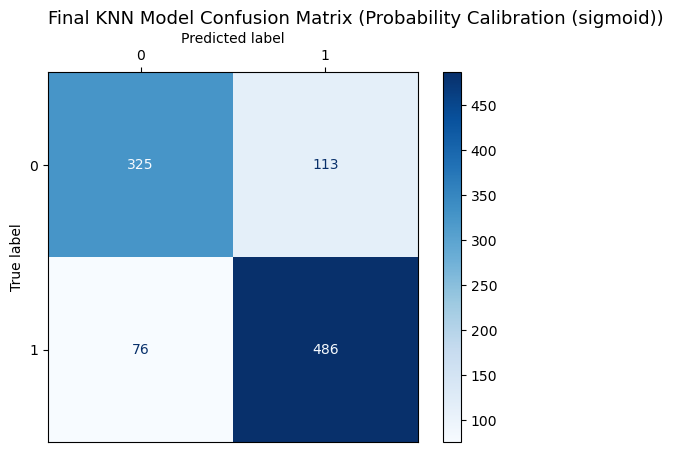

In [13]:
chosen = candidate_models[best_stage_name]

# the Youden's J candidate is stored as (pipeline, threshold) since it needs custom predict logic
if isinstance(chosen, tuple):
    inner_pipeline, final_threshold = chosen
    inner_pipeline.fit(X_train_raw, y_train)
    final_model_to_save = ThresholdedClassifier(inner_pipeline, threshold=final_threshold)
    final_model_to_save.classes_ = inner_pipeline.classes_
    final_pred = final_model_to_save.predict(X_test_raw)
    print(f"Final model is '{best_stage_name}' with a custom threshold of {final_threshold:.4f}")
else:
    final_pipeline = chosen
    final_pipeline.fit(X_train_raw, y_train)
    final_pred = final_pipeline.predict(X_test_raw)
    final_model_to_save = final_pipeline

test_accuracy = log_test(f"FINAL: {best_stage_name}", y_test, final_pred)
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.title(f"Final KNN Model Confusion Matrix ({best_stage_name})", fontsize=13, loc='left')
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)
plt.show()

**Important note for `app.py`:** the saved model below is a full `Pipeline` (feature selection + scaling + classifier combined), not a bare classifier. If `app.py` currently applies its own manual scaling/feature-selection before calling `.predict()`, that logic should be **removed** — passing already-scaled/selected data into this pipeline would scale and select twice. `app.py` should instead pass the full raw feature row directly to `final_model.predict()`, and let the pipeline handle selection and scaling internally, exactly as it did during training.

## Permutation Importance

In [14]:
from sklearn.inspection import permutation_importance

# Run permutation importance on the test set using the fitted pipeline
pi_result = permutation_importance(
    final_model_to_save, 
    X_test_raw, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

# Sort and display feature importances
sorted_importances_idx = pi_result.importances_mean.argsort()[::-1]
for i in sorted_importances_idx:
    print(f"{X_test_raw.columns[i]:<30}: {pi_result.importances_mean[i]:.4f} +/- {pi_result.importances_std[i]:.4f}")

cp_atypical angina            : 0.0286 +/- 0.0056
sex_Male                      : 0.0263 +/- 0.0053
thal_normal                   : 0.0165 +/- 0.0029
restecg_st-t abnormality      : 0.0139 +/- 0.0032
cp_non-anginal                : 0.0123 +/- 0.0052
exang_True                    : 0.0119 +/- 0.0045
fbs_missing                   : 0.0087 +/- 0.0037
data_was_missing              : 0.0082 +/- 0.0020
oldpeak                       : 0.0075 +/- 0.0037
trestbps                      : 0.0072 +/- 0.0065
hr_reserve                    : 0.0066 +/- 0.0041
chol_category_missing         : 0.0066 +/- 0.0034
risk_flag_count               : 0.0064 +/- 0.0030
slope_upsloping               : 0.0064 +/- 0.0027
oldpeak_x_flat_slope          : 0.0053 +/- 0.0025
slope_flat                    : 0.0032 +/- 0.0036
thalch                        : 0.0030 +/- 0.0027
thal_reversable defect        : 0.0027 +/- 0.0042
ca_was_missing                : 0.0025 +/- 0.0026
restecg_normal                : 0.0012 +/- 0.0032


## 8. Full Accuracy Progression Log

In [15]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy,Type
0,Baseline (n_neighbors=15),0.783026,CV (train only)
1,Grid Search Tuned,0.806049,CV (train only)
2,Grid Search + Youden's J,0.805556,CV (train only)
3,Gaussian Weighted Voting,0.803303,CV (train only)
4,Probability Calibration (sigmoid),0.810557,CV (train only)
5,FINAL: Probability Calibration (sigmoid),0.811000,"TEST (final, touched once)"


In [16]:
# save the trained model
try:
    joblib.dump(final_model_to_save, 'knn_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print(f"Model saved successfully! ('{best_stage_name}', test accuracy = {test_accuracy:.4f})")

Model saved successfully! ('Probability Calibration (sigmoid)', test accuracy = 0.8110)
